# Task 3 - Feature-Based ML Forecasting (Cach 3)

Notebook nay giai bai `Sales Forecasting` theo huong **machine learning co feature engineering** thay vi chi keo dai xu huong tu `sales.csv`.

Y tuong chinh:
- `sales.csv` van duoc dung lam nhan (`Revenue`, `COGS`).
- Cac bang con lai trong `dataset/` duoc tong hop thanh **tin hieu phu tro theo ngay**.
- Vi du lieu phu chi co den cuoi 2022, ta bien no thanh **profile theo lich** (month-day, month-weekday) de co the dung cho 2023-2024 ma khong bi leakage.
- Mo hinh dung **ridge regression tren log target** + **lag/rolling features** + **calendar profiles**.
- Du bao duoc chay theo kieu **recursive walk-forward** cho dung tinh chat time series.

Muc tieu dau ra:
- Danh gia nhanh tren nam 2022.
- Tao file `dataset/submission.csv` dung format nop bai.

## 1. Imports & Config

Cell nay chi lam 3 viec:
1. Import thu vien.
2. Khai bao duong dan file.
3. Dat cac hyper-parameter co ban cho feature engineering.

In [1]:
from pathlib import Path

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

warnings.filterwarnings('ignore', category=pd.errors.PerformanceWarning)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

DATA_DIR = Path('dataset')
TRAIN_FILE = DATA_DIR / 'sales.csv'
TEST_FILE = DATA_DIR / 'sample_submission.csv'
OUT_FILE = DATA_DIR / 'submission.csv'

LAGS = [1, 7, 14, 28, 56, 91, 182, 364]
ROLL_WINDOWS = [7, 14, 28, 56, 91, 182, 364]
MARGIN_LAGS = [1, 7, 28, 91, 364]
RIDGE_ALPHA = 50.0

## 2. Load Data

Chu y:
- Chi doc nhung cot can thiet de notebook nhe hon.
- `sales.csv` la target train.
- `sample_submission.csv` chi dung de lay danh sach ngay can du bao.

In [2]:
def load_data(data_dir: Path):
    sales = pd.read_csv(data_dir / 'sales.csv', parse_dates=['Date']).rename(columns={'Date': 'date'})
    test = pd.read_csv(data_dir / 'sample_submission.csv', parse_dates=['Date']).rename(columns={'Date': 'date'})

    orders = pd.read_csv(
        data_dir / 'orders.csv',
        usecols=['order_id', 'order_date', 'customer_id', 'order_status', 'payment_method', 'device_type', 'order_source', 'zip'],
        parse_dates=['order_date'],
    )
    items = pd.read_csv(
        data_dir / 'order_items.csv',
        usecols=['order_id', 'product_id', 'quantity', 'unit_price', 'discount_amount'],
    )
    products = pd.read_csv(
        data_dir / 'products.csv',
        usecols=['product_id', 'category', 'cogs'],
    )
    payments = pd.read_csv(
        data_dir / 'payments.csv',
        usecols=['order_id', 'payment_value', 'installments'],
    )
    shipments = pd.read_csv(
        data_dir / 'shipments.csv',
        usecols=['order_id', 'ship_date', 'delivery_date', 'shipping_fee'],
        parse_dates=['ship_date', 'delivery_date'],
    )
    returns = pd.read_csv(
        data_dir / 'returns.csv',
        usecols=['return_id', 'return_date', 'return_reason', 'return_quantity', 'refund_amount'],
        parse_dates=['return_date'],
    )
    reviews = pd.read_csv(
        data_dir / 'reviews.csv',
        usecols=['review_id', 'review_date', 'rating'],
        parse_dates=['review_date'],
    )
    customers = pd.read_csv(
        data_dir / 'customers.csv',
        usecols=['customer_id', 'signup_date', 'gender', 'acquisition_channel'],
        parse_dates=['signup_date'],
    )
    promotions = pd.read_csv(
        data_dir / 'promotions.csv',
        usecols=['promo_type', 'discount_value', 'start_date', 'end_date', 'applicable_category', 'promo_channel', 'stackable_flag'],
        parse_dates=['start_date', 'end_date'],
    )
    inventory = pd.read_csv(
        data_dir / 'inventory.csv',
        usecols=['snapshot_date', 'stock_on_hand', 'units_received', 'units_sold', 'stockout_days', 'days_of_supply', 'fill_rate', 'stockout_flag', 'overstock_flag', 'reorder_flag', 'sell_through_rate'],
        parse_dates=['snapshot_date'],
    )
    web = pd.read_csv(
        data_dir / 'web_traffic.csv',
        usecols=['date', 'sessions', 'unique_visitors', 'page_views', 'bounce_rate', 'avg_session_duration_sec', 'traffic_source'],
        parse_dates=['date'],
    )
    geography = pd.read_csv(
        data_dir / 'geography.csv',
        usecols=['zip', 'region'],
    )

    return {
        'sales': sales,
        'test': test,
        'orders': orders,
        'items': items,
        'products': products,
        'payments': payments,
        'shipments': shipments,
        'returns': returns,
        'reviews': reviews,
        'customers': customers,
        'promotions': promotions,
        'inventory': inventory,
        'web': web,
        'geography': geography,
    }


data = load_data(DATA_DIR)

In [3]:
summary_rows = []
for name, df in data.items():
    date_cols = [c for c in df.columns if 'date' in c.lower()]
    date_min = None
    date_max = None
    if date_cols:
        first_date_col = date_cols[0]
        if pd.api.types.is_datetime64_any_dtype(df[first_date_col]):
            date_min = df[first_date_col].min()
            date_max = df[first_date_col].max()
    summary_rows.append({
        'table': name,
        'rows': len(df),
        'cols': len(df.columns),
        'date_col': date_cols[0] if date_cols else None,
        'date_min': date_min,
        'date_max': date_max,
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,table,rows,cols,date_col,date_min,date_max
0,sales,3833,3,date,2012-07-04,2022-12-31
1,test,548,3,date,2023-01-01,2024-07-01
2,orders,646945,8,order_date,2012-07-04,2022-12-31
3,items,714669,5,NaN,NaT,NaT
4,products,2412,3,NaN,NaT,NaT
5,payments,646945,3,NaN,NaT,NaT
6,shipments,566067,4,ship_date,2012-07-04,2022-12-29
7,returns,39939,5,return_date,2012-07-11,2022-12-31
8,reviews,113551,3,review_date,2012-07-10,2022-12-31
9,customers,121930,4,signup_date,2012-01-17,2022-12-31


## 3. Helper Functions

`safe_div`: chia an toan de tranh chia cho 0.

`build_auxiliary_profiles`:
- Tong hop cac bang phu thanh chi so theo ngay.
- Chuyen cac chi so nay thanh profile theo lich.

`build_model_frame`:
- Tao bo khung train + future dates.
- Tron calendar features, profile features, lag features, rolling features.

`fit_ridge` + `recursive_forecast`:
- Hoc mo hinh tren log target.
- Du bao tung ngay mot theo kieu walk-forward.

In [4]:
def safe_div(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    out = np.zeros_like(a, dtype=float)
    np.divide(a, b, out=out, where=np.abs(b) > 1e-9)
    return out


def build_auxiliary_profiles(data_dict):
    sales = data_dict['sales']
    orders = data_dict['orders']
    items = data_dict['items']
    products = data_dict['products']
    payments = data_dict['payments']
    shipments = data_dict['shipments']
    returns = data_dict['returns']
    reviews = data_dict['reviews']
    customers = data_dict['customers']
    promotions = data_dict['promotions']
    inventory = data_dict['inventory']
    web = data_dict['web']
    geography = data_dict['geography']

    item_prod = items.merge(products, on='product_id', how='left')
    item_prod['net_item_revenue'] = item_prod['quantity'] * item_prod['unit_price'] - item_prod['discount_amount']
    for category in ['Streetwear', 'Outdoor', 'Casual']:
        item_prod[f'{category.lower()}_units'] = np.where(item_prod['category'].eq(category), item_prod['quantity'], 0)

    order_item_daily = (
        item_prod.merge(orders[['order_id', 'order_date']], on='order_id', how='left')
        .groupby('order_date', as_index=False)
        .agg(
            units=('quantity', 'sum'),
            discount_amount=('discount_amount', 'sum'),
            payment_value_proxy=('net_item_revenue', 'sum'),
            streetwear_units=('streetwear_units', 'sum'),
            outdoor_units=('outdoor_units', 'sum'),
            casual_units=('casual_units', 'sum'),
        )
        .rename(columns={'order_date': 'date'})
    )
    for base in ['streetwear', 'outdoor', 'casual']:
        order_item_daily[f'{base}_unit_share'] = safe_div(order_item_daily[f'{base}_units'], order_item_daily['units'])

    order_daily = (
        orders.groupby('order_date', as_index=False)
        .agg(
            order_count=('order_id', 'size'),
            customer_count=('customer_id', 'nunique'),
            returned_orders=('order_status', lambda s: (s == 'returned').sum()),
            cancelled_orders=('order_status', lambda s: (s == 'cancelled').sum()),
            mobile_orders=('device_type', lambda s: (s == 'mobile').sum()),
            credit_card_orders=('payment_method', lambda s: (s == 'credit_card').sum()),
            paid_search_orders=('order_source', lambda s: (s == 'paid_search').sum()),
            organic_search_orders=('order_source', lambda s: (s == 'organic_search').sum()),
            social_orders=('order_source', lambda s: (s == 'social_media').sum()),
            email_orders=('order_source', lambda s: (s == 'email_campaign').sum()),
        )
        .rename(columns={'order_date': 'date'})
    )
    for base in ['returned', 'cancelled', 'mobile', 'credit_card', 'paid_search', 'organic_search', 'social', 'email']:
        order_daily[f'{base}_share'] = safe_div(order_daily[f'{base}_orders'], order_daily['order_count'])

    order_geo = orders.merge(geography, on='zip', how='left')
    for region_name in ['East', 'Central', 'West']:
        order_geo[f'{region_name}_orders'] = (order_geo['region'] == region_name).astype(int)
    order_geo_daily = (
        order_geo.groupby('order_date', as_index=False)
        .agg(
            East_orders=('East_orders', 'sum'),
            Central_orders=('Central_orders', 'sum'),
            West_orders=('West_orders', 'sum'),
        )
        .rename(columns={'order_date': 'date'})
    )
    region_total = order_geo_daily[['East_orders', 'Central_orders', 'West_orders']].sum(axis=1)
    order_geo_daily['east_region_share'] = safe_div(order_geo_daily['East_orders'], region_total)
    order_geo_daily['central_region_share'] = safe_div(order_geo_daily['Central_orders'], region_total)
    order_geo_daily['west_region_share'] = safe_div(order_geo_daily['West_orders'], region_total)

    payment_daily = (
        payments.merge(orders[['order_id', 'order_date']], on='order_id', how='left')
        .groupby('order_date', as_index=False)
        .agg(payment_value=('payment_value', 'sum'), mean_installments=('installments', 'mean'))
        .rename(columns={'order_date': 'date'})
    )

    shipments = shipments.copy()
    shipments['delivery_days'] = (shipments['delivery_date'] - shipments['ship_date']).dt.days
    shipment_daily = (
        shipments.merge(orders[['order_id', 'order_date']], on='order_id', how='left')
        .groupby('order_date', as_index=False)
        .agg(shipping_fee=('shipping_fee', 'sum'), avg_delivery_days=('delivery_days', 'mean'))
        .rename(columns={'order_date': 'date'})
    )

    return_daily = (
        returns.groupby('return_date', as_index=False)
        .agg(
            return_count=('return_id', 'size'),
            return_qty=('return_quantity', 'sum'),
            refund_amount=('refund_amount', 'sum'),
            late_delivery_returns=('return_reason', lambda s: (s == 'late_delivery').sum()),
            wrong_size_returns=('return_reason', lambda s: (s == 'wrong_size').sum()),
        )
        .rename(columns={'return_date': 'date'})
    )
    for base in ['late_delivery', 'wrong_size']:
        return_daily[f'{base}_share'] = safe_div(return_daily[f'{base}_returns'], return_daily['return_count'])

    review_daily = (
        reviews.groupby('review_date', as_index=False)
        .agg(
            review_count=('review_id', 'size'),
            rating_mean=('rating', 'mean'),
            low_rating_count=('rating', lambda s: (s <= 2).sum()),
        )
        .rename(columns={'review_date': 'date'})
    )
    review_daily['low_rating_share'] = safe_div(review_daily['low_rating_count'], review_daily['review_count'])

    signup_daily = (
        customers.groupby('signup_date', as_index=False)
        .agg(
            signup_count=('customer_id', 'size'),
            female_signups=('gender', lambda s: (s == 'Female').sum()),
            social_signups=('acquisition_channel', lambda s: (s == 'social_media').sum()),
        )
        .rename(columns={'signup_date': 'date'})
    )
    signup_daily['female_signup_share'] = safe_div(signup_daily['female_signups'], signup_daily['signup_count'])
    signup_daily['social_signup_share'] = safe_div(signup_daily['social_signups'], signup_daily['signup_count'])

    promo_frames = []
    for row in promotions.itertuples(index=False):
        days = pd.DataFrame({'date': pd.date_range(row.start_date, row.end_date, freq='D')})
        days['active_promo_count'] = 1
        days['promo_discount_value'] = float(row.discount_value)
        days['percentage_promo_count'] = int(row.promo_type == 'percentage')
        days['fixed_promo_count'] = int(row.promo_type == 'fixed')
        days['stackable_promo_count'] = int(row.stackable_flag)
        days['promo_online_count'] = int(row.promo_channel == 'online')
        days['promo_all_channel_count'] = int(row.promo_channel == 'all_channels')
        days['promo_email_count'] = int(row.promo_channel == 'email')
        days['promo_social_count'] = int(row.promo_channel == 'social_media')
        days['promo_streetwear_count'] = int(str(row.applicable_category) == 'Streetwear')
        days['promo_outdoor_count'] = int(str(row.applicable_category) == 'Outdoor')
        promo_frames.append(days)
    promo_daily = pd.concat(promo_frames, ignore_index=True).groupby('date', as_index=False).sum()

    calendar = pd.DataFrame({'date': pd.date_range(sales['date'].min(), sales['date'].max(), freq='D')})
    inventory_daily = (
        inventory.groupby('snapshot_date', as_index=False)
        .agg(
            stock_on_hand=('stock_on_hand', 'sum'),
            units_received=('units_received', 'sum'),
            inv_units_sold=('units_sold', 'sum'),
            stockout_days=('stockout_days', 'sum'),
            days_of_supply=('days_of_supply', 'mean'),
            fill_rate=('fill_rate', 'mean'),
            stockout_flag=('stockout_flag', 'mean'),
            overstock_flag=('overstock_flag', 'mean'),
            reorder_flag=('reorder_flag', 'mean'),
            sell_through_rate=('sell_through_rate', 'mean'),
        )
        .rename(columns={'snapshot_date': 'date'})
    )
    inventory_daily = calendar.merge(inventory_daily, on='date', how='left').sort_values('date')
    inventory_daily.iloc[:, 1:] = inventory_daily.iloc[:, 1:].ffill().fillna(0)

    web_total = (
        web.groupby('date', as_index=False)
        .agg(
            sessions=('sessions', 'sum'),
            unique_visitors=('unique_visitors', 'sum'),
            page_views=('page_views', 'sum'),
            bounce_rate=('bounce_rate', 'mean'),
            avg_session_duration_sec=('avg_session_duration_sec', 'mean'),
        )
    )
    web_sources = web.pivot_table(index='date', columns='traffic_source', values='sessions', aggfunc='sum', fill_value=0).reset_index()
    web_sources.columns = ['date'] + [f'{name}_sessions' for name in web_sources.columns[1:]]
    web_daily = web_total.merge(web_sources, on='date', how='left')
    for source_name in ['organic_search', 'paid_search', 'social_media', 'email_campaign']:
        col = f'{source_name}_sessions'
        if col in web_daily.columns:
            web_daily[f'{source_name}_share'] = safe_div(web_daily[col], web_daily['sessions'])

    aux = calendar.copy()
    for part in [order_daily, order_item_daily, order_geo_daily, payment_daily, shipment_daily, return_daily, review_daily, signup_daily, promo_daily, inventory_daily, web_daily]:
        aux = aux.merge(part, on='date', how='left')
    aux = aux.sort_values('date').fillna(0)
    aux['month'] = aux['date'].dt.month
    aux['day'] = aux['date'].dt.day
    aux['dow'] = aux['date'].dt.dayofweek

    profile_cols = [c for c in aux.columns if c not in {'date', 'month', 'day', 'dow'}]
    md_profile = aux.groupby(['month', 'day'])[profile_cols].mean().reset_index().rename(columns={c: f'md_{c}' for c in profile_cols})
    mwd_profile = aux.groupby(['month', 'dow'])[profile_cols].mean().reset_index().rename(columns={c: f'mwd_{c}' for c in profile_cols})

    sales_calendar = sales.copy()
    sales_calendar['month'] = sales_calendar['date'].dt.month
    sales_calendar['day'] = sales_calendar['date'].dt.day
    sales_calendar['dow'] = sales_calendar['date'].dt.dayofweek
    sales_md = sales_calendar.groupby(['month', 'day'])[['Revenue', 'COGS']].mean().reset_index().rename(
        columns={'Revenue': 'sales_md_revenue_mean', 'COGS': 'sales_md_cogs_mean'}
    )
    sales_mwd = sales_calendar.groupby(['month', 'dow'])[['Revenue', 'COGS']].mean().reset_index().rename(
        columns={'Revenue': 'sales_mwd_revenue_mean', 'COGS': 'sales_mwd_cogs_mean'}
    )

    return md_profile, mwd_profile, sales_md, sales_mwd


def build_model_frame(data_dict, md_profile, mwd_profile, sales_md, sales_mwd):
    sales = data_dict['sales']
    future_dates = data_dict['test'][['date']].copy()

    full = pd.concat([sales[['date']], future_dates], ignore_index=True).drop_duplicates().sort_values('date').reset_index(drop=True)
    full['month'] = full['date'].dt.month
    full['day'] = full['date'].dt.day
    full['dow'] = full['date'].dt.dayofweek
    full['doy'] = full['date'].dt.dayofyear
    full['weekofyear'] = full['date'].dt.isocalendar().week.astype(int)
    full['quarter'] = full['date'].dt.quarter
    full['is_weekend'] = (full['dow'] >= 5).astype(int)
    full['is_month_start'] = full['date'].dt.is_month_start.astype(int)
    full['is_month_end'] = full['date'].dt.is_month_end.astype(int)
    for period, prefix in [(7, 'week'), (30.5, 'month'), (365.25, 'year')]:
        full[f'{prefix}_sin'] = np.sin(2 * np.pi * full['doy'] / period)
        full[f'{prefix}_cos'] = np.cos(2 * np.pi * full['doy'] / period)

    full = (
        full.merge(md_profile, on=['month', 'day'], how='left')
        .merge(mwd_profile, on=['month', 'dow'], how='left')
        .merge(sales_md, on=['month', 'day'], how='left')
        .merge(sales_mwd, on=['month', 'dow'], how='left')
        .merge(sales, on='date', how='left')
    )

    for target in ['Revenue', 'COGS']:
        base = target.lower()
        full[target] = full[target].astype(float)
        for lag in LAGS:
            full[f'{base}_lag_{lag}'] = full[target].shift(lag)
        for win in ROLL_WINDOWS:
            full[f'{base}_roll_mean_{win}'] = full[target].shift(1).rolling(win).mean()
            full[f'{base}_roll_std_{win}'] = full[target].shift(1).rolling(win).std()

    full['margin_ratio'] = safe_div(full['Revenue'] - full['COGS'], full['Revenue'])
    for lag in MARGIN_LAGS:
        full[f'margin_ratio_lag_{lag}'] = full['margin_ratio'].shift(lag)

    feature_cols = [
        'month', 'day', 'dow', 'doy', 'weekofyear', 'quarter',
        'is_weekend', 'is_month_start', 'is_month_end',
        'week_sin', 'week_cos', 'month_sin', 'month_cos', 'year_sin', 'year_cos',
        'sales_md_revenue_mean', 'sales_md_cogs_mean', 'sales_mwd_revenue_mean', 'sales_mwd_cogs_mean',
    ]
    feature_cols += [c for c in full.columns if c.startswith('md_') or c.startswith('mwd_')]
    for target in ['revenue', 'cogs']:
        feature_cols += [f'{target}_lag_{lag}' for lag in LAGS]
        feature_cols += [f'{target}_roll_mean_{win}' for win in ROLL_WINDOWS]
        feature_cols += [f'{target}_roll_std_{win}' for win in ROLL_WINDOWS]
    feature_cols += [f'margin_ratio_lag_{lag}' for lag in MARGIN_LAGS]

    return full, feature_cols


def fit_ridge(X, y, alpha=RIDGE_ALPHA):
    mu = X.mean(axis=0)
    sigma = X.std(axis=0)
    sigma[sigma < 1e-8] = 1.0
    Xs = (X - mu) / sigma
    Xb = np.column_stack([np.ones(len(Xs)), Xs])
    penalty = np.eye(Xb.shape[1])
    penalty[0, 0] = 0.0
    beta = np.linalg.solve(Xb.T @ Xb + alpha * penalty, Xb.T @ y)
    return {'mu': mu, 'sigma': sigma, 'beta': beta}


def predict_ridge(model, X):
    Xs = (X - model['mu']) / model['sigma']
    Xb = np.column_stack([np.ones(len(Xs)), Xs])
    return Xb @ model['beta']


def prepare_train_matrix(frame, feature_cols, train_end):
    train_df = frame[(frame['date'] <= train_end) & frame['revenue_lag_364'].notna() & frame['cogs_lag_364'].notna()].copy()
    train_df[feature_cols] = train_df[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
    return train_df


def recursive_forecast(frame, feature_cols, rev_model, cogs_model, start_date, end_date):
    work = frame.copy().set_index('date')
    for current_date in pd.date_range(start_date, end_date, freq='D'):
        for target in ['Revenue', 'COGS']:
            base = target.lower()
            for lag in LAGS:
                work.loc[current_date, f'{base}_lag_{lag}'] = work.loc[current_date - pd.Timedelta(days=lag), target]
            hist = work.loc[:current_date - pd.Timedelta(days=1), target]
            for win in ROLL_WINDOWS:
                window = hist.tail(win)
                work.loc[current_date, f'{base}_roll_mean_{win}'] = window.mean()
                work.loc[current_date, f'{base}_roll_std_{win}'] = window.std(ddof=1)

        hist_margin = (
            (work.loc[:current_date - pd.Timedelta(days=1), 'Revenue'] - work.loc[:current_date - pd.Timedelta(days=1), 'COGS'])
            / work.loc[:current_date - pd.Timedelta(days=1), 'Revenue'].replace(0, np.nan)
        ).fillna(0)
        for lag in MARGIN_LAGS:
            work.loc[current_date, f'margin_ratio_lag_{lag}'] = hist_margin.loc[current_date - pd.Timedelta(days=lag)]

        row = work.loc[[current_date], feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0).to_numpy(float)
        work.loc[current_date, 'Revenue'] = max(np.expm1(predict_ridge(rev_model, row))[0], 0.0)
        work.loc[current_date, 'COGS'] = max(np.expm1(predict_ridge(cogs_model, row))[0], 0.0)

    return work.reset_index()


def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    r2 = 1 - np.sum((y_true - y_pred) ** 2) / np.sum((y_true - y_true.mean()) ** 2)
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2}


def extract_top_coefficients(model, feature_cols, top_n=15):
    coef = pd.Series(np.abs(model['beta'][1:]), index=feature_cols)
    return coef.sort_values(ascending=False).head(top_n)

## 4. Build Profiles & Model Frame

Den day ta chua train gi ca. Ta moi bien du lieu raw thanh bo feature co the dung cho train va future.

In [5]:
md_profile, mwd_profile, sales_md, sales_mwd = build_auxiliary_profiles(data)
frame, feature_cols = build_model_frame(data, md_profile, mwd_profile, sales_md, sales_mwd)

print('Model frame shape:', frame.shape)
print('Feature count    :', len(feature_cols))
frame[['date', 'Revenue', 'COGS'] + feature_cols[:8]].head()

Model frame shape: (4381, 250)
Feature count    : 246


,date,Revenue,COGS,month,day,dow,doy,weekofyear,quarter,is_weekend,is_month_start
0,2012-07-04,"5,123,547.94","3,982,991.19",7,4,2,186,27,3,0,0
1,2012-07-05,"2,751,773.45","2,150,580.23",7,5,3,187,27,3,0,0
2,2012-07-06,"3,054,029.42","2,517,632.84",7,6,4,188,27,3,0,0
3,2012-07-07,"2,667,930.94","2,108,246.62",7,7,5,189,27,3,1,0
4,2012-07-08,"2,360,851.90","1,808,622.79",7,8,6,190,27,3,1,0


## 5. Walk-Forward Validation on 2022

Cach validate nay hop ly hon cho time series:
- Train bang du lieu den het 2021.
- Du bao tung ngay cua 2022 theo kieu recursive.
- So sanh prediction voi gia tri that.

In [6]:
train_2021 = prepare_train_matrix(frame, feature_cols, pd.Timestamp('2021-12-31'))

revenue_model_2021 = fit_ridge(
    train_2021[feature_cols].to_numpy(float),
    np.log1p(train_2021['Revenue'].to_numpy(float)),
)
cogs_model_2021 = fit_ridge(
    train_2021[feature_cols].to_numpy(float),
    np.log1p(train_2021['COGS'].to_numpy(float)),
)

valid_forecast = recursive_forecast(
    frame,
    feature_cols,
    revenue_model_2021,
    cogs_model_2021,
    pd.Timestamp('2022-01-01'),
    pd.Timestamp('2022-12-31'),
)

actual_2022 = frame[(frame['date'] >= '2022-01-01') & (frame['date'] <= '2022-12-31')][['date', 'Revenue', 'COGS']].copy()
pred_2022 = valid_forecast[(valid_forecast['date'] >= '2022-01-01') & (valid_forecast['date'] <= '2022-12-31')][['date', 'Revenue', 'COGS']].copy()
merged_2022 = actual_2022.merge(pred_2022, on='date', suffixes=('_actual', '_pred'))

metrics_2022 = pd.DataFrame([
    {'target': 'Revenue', **compute_metrics(merged_2022['Revenue_actual'], merged_2022['Revenue_pred'])},
    {'target': 'COGS', **compute_metrics(merged_2022['COGS_actual'], merged_2022['COGS_pred'])},
])
metrics_2022

,target,MAE,RMSE,R2
0,Revenue,"603,520.84","808,694.51",0.77
1,COGS,"572,348.42","756,149.16",0.73


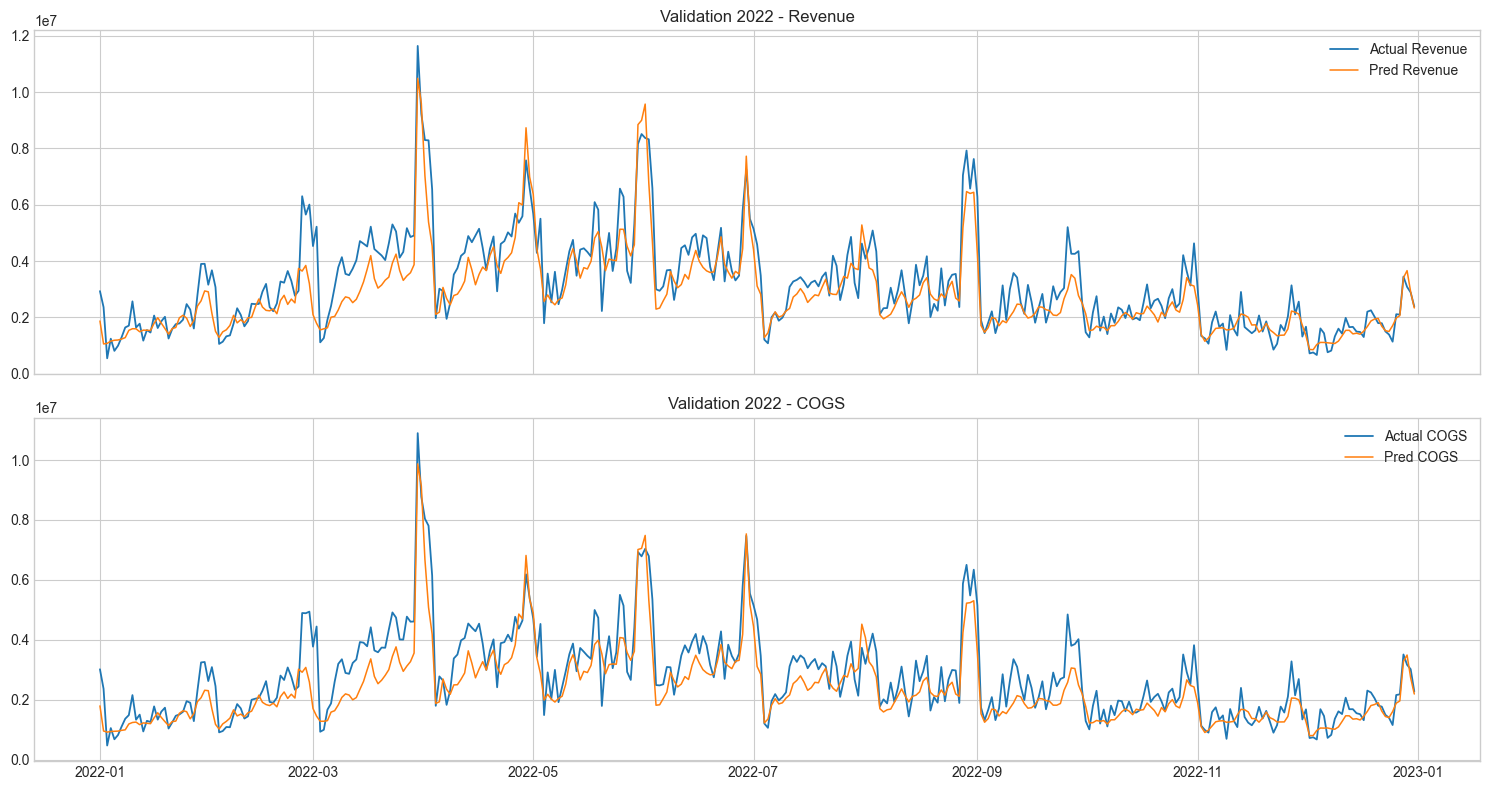

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

axes[0].plot(merged_2022['date'], merged_2022['Revenue_actual'], label='Actual Revenue', linewidth=1.3)
axes[0].plot(merged_2022['date'], merged_2022['Revenue_pred'], label='Pred Revenue', linewidth=1.1)
axes[0].set_title('Validation 2022 - Revenue')
axes[0].legend()

axes[1].plot(merged_2022['date'], merged_2022['COGS_actual'], label='Actual COGS', linewidth=1.3)
axes[1].plot(merged_2022['date'], merged_2022['COGS_pred'], label='Pred COGS', linewidth=1.1)
axes[1].set_title('Validation 2022 - COGS')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Feature Importance (He so lon nhat)

Vi day la ridge regression sau khi standardize feature, do lon he so co the dung lam mot cach doc nhanh xem mo hinh dang dua vao nhom tin hieu nao.

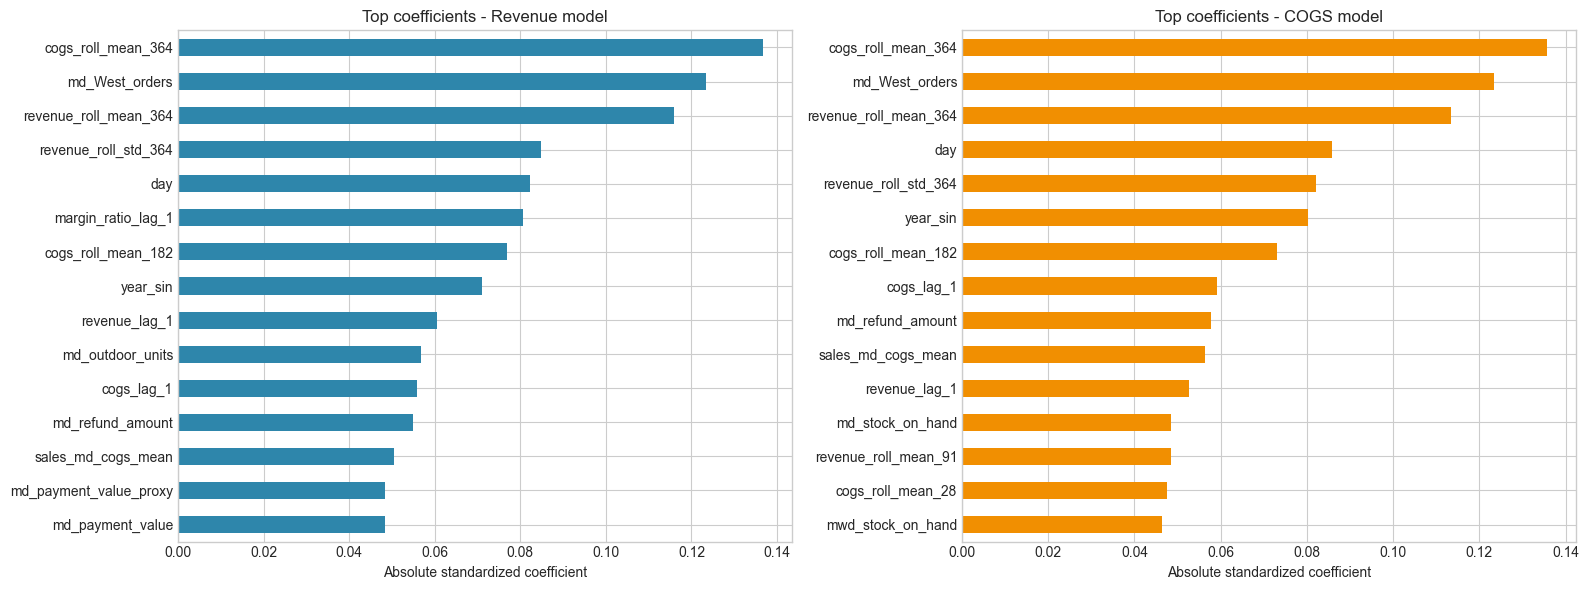

,Revenue_top_features,Revenue_abs_coef
0,cogs_roll_mean_364,0.14
1,md_West_orders,0.12
2,revenue_roll_mean_364,0.12
3,revenue_roll_std_364,0.08
4,day,0.08
5,margin_ratio_lag_1,0.08
6,cogs_roll_mean_182,0.08
7,year_sin,0.07
8,revenue_lag_1,0.06
9,md_outdoor_units,0.06


,COGS_top_features,COGS_abs_coef
0,cogs_roll_mean_364,0.14
1,md_West_orders,0.12
2,revenue_roll_mean_364,0.11
3,day,0.09
4,revenue_roll_std_364,0.08
5,year_sin,0.08
6,cogs_roll_mean_182,0.07
7,cogs_lag_1,0.06
8,md_refund_amount,0.06
9,sales_md_cogs_mean,0.06


In [8]:
top_rev = extract_top_coefficients(revenue_model_2021, feature_cols, top_n=15)
top_cogs = extract_top_coefficients(cogs_model_2021, feature_cols, top_n=15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_rev.sort_values().plot(kind='barh', ax=axes[0], color='#2E86AB')
axes[0].set_title('Top coefficients - Revenue model')
axes[0].set_xlabel('Absolute standardized coefficient')

top_cogs.sort_values().plot(kind='barh', ax=axes[1], color='#F18F01')
axes[1].set_title('Top coefficients - COGS model')
axes[1].set_xlabel('Absolute standardized coefficient')

plt.tight_layout()
plt.show()

display(pd.DataFrame({'Revenue_top_features': top_rev.index, 'Revenue_abs_coef': top_rev.values}))
display(pd.DataFrame({'COGS_top_features': top_cogs.index, 'COGS_abs_coef': top_cogs.values}))

## 7. Final Training on Full History & Forecast Test

Sau khi validate xong, ta train lai tren toan bo giai doan 2012-2022 roi du bao cho 2023-01-01 -> 2024-07-01.

In [9]:
train_full = prepare_train_matrix(frame, feature_cols, pd.Timestamp('2022-12-31'))

revenue_model_full = fit_ridge(
    train_full[feature_cols].to_numpy(float),
    np.log1p(train_full['Revenue'].to_numpy(float)),
)
cogs_model_full = fit_ridge(
    train_full[feature_cols].to_numpy(float),
    np.log1p(train_full['COGS'].to_numpy(float)),
)

future_forecast = recursive_forecast(
    frame,
    feature_cols,
    revenue_model_full,
    cogs_model_full,
    pd.Timestamp('2023-01-01'),
    pd.Timestamp('2024-07-01'),
)

submission = data['test'][['date']].merge(
    future_forecast[['date', 'Revenue', 'COGS']],
    on='date',
    how='left',
)
submission = submission.rename(columns={'date': 'Date'})
submission.to_csv(OUT_FILE, index=False)

print('Saved to:', OUT_FILE)
print('Submission shape:', submission.shape)
submission.head(10)

Saved to: dataset/submission.csv
Submission shape: (548, 3)


,Date,Revenue,COGS
0,2023-01-01,"2,379,921.12","2,142,295.04"
1,2023-01-02,"1,438,334.48","1,255,832.91"
2,2023-01-03,"1,177,398.71","975,197.05"
3,2023-01-04,"1,169,279.52","933,121.96"
4,2023-01-05,"1,226,397.13","972,171.98"
5,2023-01-06,"1,279,122.18","1,006,933.78"
6,2023-01-07,"1,369,819.38","1,078,562.74"
7,2023-01-08,"1,558,587.95","1,205,586.20"
8,2023-01-09,"1,790,753.50","1,380,217.65"
9,2023-01-10,"1,647,187.16","1,288,004.12"


In [10]:
submission.tail(10)

,Date,Revenue,COGS
538,2024-06-22,"4,030,770.59","3,181,940.99"
539,2024-06-23,"3,846,662.51","3,205,056.28"
540,2024-06-24,"4,247,489.46","3,661,346.78"
541,2024-06-25,"4,057,799.37","3,640,894.87"
542,2024-06-26,"4,350,854.16","4,009,694.16"
543,2024-06-27,"3,476,979.28","3,327,998.91"
544,2024-06-28,"3,843,299.50","3,718,344.29"
545,2024-06-29,"6,352,322.86","6,301,271.85"
546,2024-06-30,"4,937,627.74","4,904,511.18"
547,2024-07-01,"4,829,764.44","4,874,450.63"


## 8. Local SHAP Explanations

Phan nay giai thich tung ngay du bao cu the. Vi mo hinh Ridge la mo hinh tuyen tinh tren feature da chuan hoa, SHAP value cua tung feature co the tinh truc tiep bang dong gop cua feature do vao log prediction. Cach nay tuong duong voi linear SHAP theo baseline la gia tri feature trung binh cua tap train, khong can cai them thu vien ngoai.

Output chinh:
- `models/shap_local_contributions.csv`: top feature keo du bao len/xuong cho cac ngay tieu bieu.
- `models/shap_business_summary.csv`: dien giai ngan gon bang ngon ngu kinh doanh.


In [ ]:
EXPLAIN_DIR = Path('models')
EXPLAIN_DIR.mkdir(exist_ok=True)


def linear_shap_contributions(model, X):
    """Exact additive contributions for the standardized linear Ridge model."""
    Xs = (X - model['mu']) / model['sigma']
    return Xs * model['beta'][1:]


def feature_business_label(feature):
    if 'roll_mean_364' in feature or 'lag_364' in feature:
        return 'same-season yearly pattern'
    if 'roll_mean' in feature or 'lag_' in feature:
        return 'recent sales momentum'
    if feature.startswith('sales_md_') or feature.startswith('sales_mwd_'):
        return 'historical sales seasonality'
    if 'promo' in feature:
        return 'promotion intensity'
    if 'stock' in feature or 'fill_rate' in feature or 'inventory' in feature:
        return 'inventory availability'
    if 'refund' in feature or 'return' in feature:
        return 'return/refund pressure'
    if 'rating' in feature or 'review' in feature:
        return 'customer satisfaction signal'
    if 'session' in feature or 'page_view' in feature or 'bounce' in feature:
        return 'web demand signal'
    if 'region' in feature or 'East' in feature or 'West' in feature or 'Central' in feature:
        return 'regional demand mix'
    if 'outdoor' in feature or 'streetwear' in feature or 'casual' in feature:
        return 'product category mix'
    if 'payment' in feature or 'installment' in feature:
        return 'payment behavior'
    if feature in ['month', 'day', 'dow', 'doy', 'weekofyear', 'quarter', 'is_weekend', 'is_month_start', 'is_month_end'] or feature.endswith('_sin') or feature.endswith('_cos'):
        return 'calendar effect'
    return 'other model signal'


def explain_dates(forecast_frame, feature_cols, model, target, selected_dates, top_n=8):
    rows = []
    for date in selected_dates:
        date = pd.Timestamp(date)
        row_df = forecast_frame.loc[forecast_frame['date'].eq(date), feature_cols]
        if row_df.empty:
            continue
        X = row_df.replace([np.inf, -np.inf], np.nan).fillna(0).to_numpy(float)
        shap_values = linear_shap_contributions(model, X)[0]
        feature_values = X[0]
        pred_log = model['beta'][0] + shap_values.sum()
        pred_value = np.expm1(pred_log)
        baseline_value = np.expm1(model['beta'][0])
        top_idx = np.argsort(np.abs(shap_values))[-top_n:][::-1]
        for idx in top_idx:
            rows.append({
                'target': target,
                'date': date,
                'predicted_value': pred_value,
                'baseline_value': baseline_value,
                'feature': feature_cols[idx],
                'feature_value': feature_values[idx],
                'shap_log_contribution': shap_values[idx],
                'direction': 'pushes forecast up' if shap_values[idx] >= 0 else 'pushes forecast down',
                'business_signal': feature_business_label(feature_cols[idx]),
            })
    return pd.DataFrame(rows)


def summarize_business_explanations(contrib_df, top_k=3):
    summary_rows = []
    for (target, date), group in contrib_df.groupby(['target', 'date']):
        up = group[group['shap_log_contribution'] > 0].sort_values('shap_log_contribution', ascending=False).head(top_k)
        down = group[group['shap_log_contribution'] < 0].sort_values('shap_log_contribution').head(top_k)
        up_text = '; '.join(f"{r.business_signal} ({r.feature})" for r in up.itertuples()) or 'no major upward driver'
        down_text = '; '.join(f"{r.business_signal} ({r.feature})" for r in down.itertuples()) or 'no major downward driver'
        prediction = group['predicted_value'].iloc[0]
        summary_rows.append({
            'target': target,
            'date': date,
            'predicted_value': prediction,
            'main_upward_drivers': up_text,
            'main_downward_drivers': down_text,
            'business_reading': (
                f"For {target}, the forecast is mainly lifted by {up_text}. "
                f"It is mainly reduced by {down_text}."
            ),
        })
    return pd.DataFrame(summary_rows).sort_values(['date', 'target']).reset_index(drop=True)


test_forecast = future_forecast[
    (future_forecast['date'] >= data['test']['date'].min())
    & (future_forecast['date'] <= data['test']['date'].max())
].copy()

revenue_by_date = test_forecast.set_index('date')['Revenue']
selected_dates = [
    data['test']['date'].min(),
    revenue_by_date.idxmax(),
    revenue_by_date.idxmin(),
    revenue_by_date.diff().idxmax(),
]
selected_dates = list(dict.fromkeys(pd.to_datetime(selected_dates)))

revenue_contrib = explain_dates(test_forecast, feature_cols, revenue_model_full, 'Revenue', selected_dates, top_n=10)
cogs_contrib = explain_dates(test_forecast, feature_cols, cogs_model_full, 'COGS', selected_dates, top_n=10)
shap_contrib = pd.concat([revenue_contrib, cogs_contrib], ignore_index=True)
shap_summary = summarize_business_explanations(shap_contrib)

shap_contrib.to_csv(EXPLAIN_DIR / 'shap_local_contributions.csv', index=False)
shap_summary.to_csv(EXPLAIN_DIR / 'shap_business_summary.csv', index=False)

print('Saved local SHAP-style contributions to:', EXPLAIN_DIR / 'shap_local_contributions.csv')
print('Saved business SHAP summary to:', EXPLAIN_DIR / 'shap_business_summary.csv')
shap_summary


Saved local SHAP-style contributions to: models/shap_local_contributions.csv
Saved business SHAP summary to: models/shap_business_summary.csv


,target,date,predicted_value,main_upward_drivers,main_downward_drivers,business_reading
0,COGS,2023-01-01,"2,142,295.04",regional demand mix (md_West_orders); product ...,same-season yearly pattern (cogs_roll_mean_364...,"For COGS, the forecast is mainly lifted by reg..."
1,Revenue,2023-01-01,"2,379,921.12",product category mix (md_outdoor_units); regio...,same-season yearly pattern (cogs_roll_mean_364...,"For Revenue, the forecast is mainly lifted by ..."
2,COGS,2023-03-30,"11,009,802.38",regional demand mix (md_West_orders); historic...,regional demand mix (md_East_orders); same-sea...,"For COGS, the forecast is mainly lifted by reg..."
3,Revenue,2023-03-30,"11,721,324.89",regional demand mix (md_West_orders); historic...,regional demand mix (md_East_orders); other mo...,"For Revenue, the forecast is mainly lifted by ..."
4,COGS,2023-05-31,"9,292,510.84",regional demand mix (md_West_orders); historic...,same-season yearly pattern (cogs_roll_mean_364...,"For COGS, the forecast is mainly lifted by reg..."
5,Revenue,2023-05-31,"11,927,210.32",regional demand mix (md_West_orders); payment ...,same-season yearly pattern (cogs_roll_mean_364...,"For Revenue, the forecast is mainly lifted by ..."
6,COGS,2023-12-02,"907,986.61",other model signal (revenue_roll_std_364),regional demand mix (md_West_orders); same-sea...,"For COGS, the forecast is mainly lifted by oth..."
7,Revenue,2023-12-02,"928,713.30",other model signal (revenue_roll_std_364),regional demand mix (md_West_orders); same-sea...,"For Revenue, the forecast is mainly lifted by ..."


## 9. Ghi Chu Quan Trong

- Notebook nay **khong** dung `Revenue`/`COGS` cua tap test de tao feature.
- Cac bang phu (`orders`, `order_items`, `products`, `payments`, `shipments`, `returns`, `reviews`, `customers`, `promotions`, `inventory`, `web_traffic`, `geography`) duoc tan dung thong qua **profile lich su**, nen van an toan cho future horizon.
- Local SHAP-style contributions duoc xuat ra `models/shap_local_contributions.csv` va `models/shap_business_summary.csv` de phuc vu report Task 3.
- Neu muon nang diem tiep, huong hop ly nhat la them ensemble giua feature-based ML va baseline seasonality, dong thoi mo rong phan giai thich local SHAP-style cho nhieu ngay du bao hon.